In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('ushape.csv')

In [3]:
X = df.iloc[:,0:2].values
y = df.iloc[:,-1].values

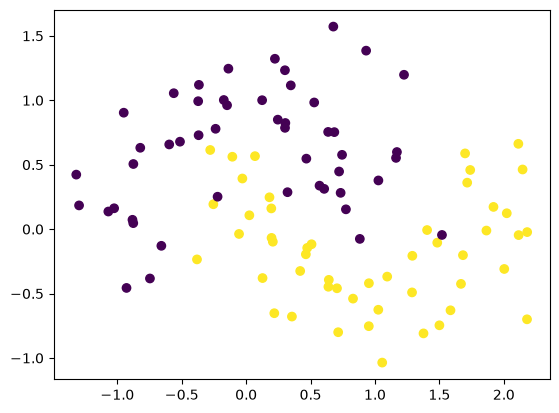

In [4]:
plt.scatter(X[:,0],X[:,1],c=y)

In [5]:
import tensorflow
from tensorflow import keras
from keras import Sequential
from keras.layers import Dense

In [6]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2,kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(10,activation='relu',kernel_initializer='he_normal'))
model.add(Dense(1,activation='sigmoid'))

model.summary()

D:\Users\HP\anaconda3\envs\dl\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 10)                  │              30 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │             110 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              11 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 371 (1.45 KB)

 Trainable params: 371 (1.45 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
model.get_weights()

[array([[ 0.27020353, -1.0847265 ,  0.35890293, -0.05656824,  0.51991254,
          0.7550255 ,  1.4513426 ,  1.1392303 ,  0.34210846, -0.86225635],
        [-1.7286037 , -1.0563446 ,  0.65546495, -0.9066005 ,  1.8587981 ,
         -0.5028069 , -0.48236555, -0.36496246,  0.04771991,  1.3718334 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[ 0.400051  ,  0.02686381, -0.17908582,  0.48685917, -0.49146158,
          0.32181963,  0.76429474, -0.35916215, -0.4467352 , -0.397146  ],
        [-0.1441957 ,  0.3321311 ,  0.82671684,  0.24462207,  0.5549285 ,
          0.30148235, -0.61163795, -0.26520428, -0.737999  ,  0.04030432],
        [-0.6738587 , -0.21879056,  0.15485243, -0.16975524,  0.42812687,
         -0.40776905,  0.37116835,  0.28197545, -0.05290036, -0.13739245],
        [ 0.4201656 ,  0.29561418, -0.453281  ,  0.09475037,  0.6553197 ,
         -0.674947  ,  0.12240214,  0.2114225 , -0.03295456,  0.15126783],
        [-0.85721

In [8]:
initial_weights = model.get_weights()

In [9]:
initial_weights[0] = np.random.randn(2,10)*np.sqrt(1/2)
initial_weights[1] = np.zeros(model.get_weights()[1].shape)
initial_weights[2] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[3] = np.zeros(model.get_weights()[3].shape)
initial_weights[4] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[5] = np.zeros(model.get_weights()[5].shape)
initial_weights[6] = np.random.randn(10,10)*np.sqrt(1/10)
initial_weights[7] = np.zeros(model.get_weights()[7].shape)
initial_weights[8] = np.random.randn(10,1)*np.sqrt(1/10)
initial_weights[9] = np.zeros(model.get_weights()[9].shape)

In [10]:
model.set_weights(initial_weights)

In [11]:
model.get_weights()

[array([[ 0.4871594 , -0.34537974,  0.79404217,  0.10073961, -0.6091206 ,
          0.69935083,  0.65793926, -0.38673756,  0.8952466 , -0.3897812 ],
        [ 0.91205186, -0.25850886,  0.310762  ,  0.31296787,  0.96641046,
          0.32873896,  0.6295362 , -0.5395606 ,  0.9404224 , -0.7118573 ]],
       dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], dtype=float32),
 array([[-0.18007411, -0.26984277, -0.11209311, -0.12775129,  0.06309067,
          0.28082228,  0.17548223, -0.4404613 , -0.3764471 ,  0.07895178],
        [ 0.36497706, -0.47326005, -0.52235496,  0.13078882,  0.85012734,
         -0.18684971,  0.49378487, -0.3860693 ,  0.06601677, -0.28990683],
        [-0.02674043, -0.10567898,  0.18509062, -0.02876018, -0.04339268,
          0.02534572, -0.26979336, -0.04409882, -0.24293737, -0.06932577],
        [ 0.01340024, -0.39114913,  0.06546568,  0.01668045,  0.43920168,
          0.02333224,  0.09784278,  0.10114538,  0.10110318,  0.16951439],
        [ 0.16753

In [12]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [13]:
history = model.fit(X,y,epochs=100,validation_split=0.2)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 424ms/step - accuracy: 0.4810 - loss: 0.6950 - val_accuracy: 0.4500 - val_loss: 0.6995
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.4810 - loss: 0.6943 - val_accuracy: 0.4500 - val_loss: 0.6979
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step - accuracy: 0.4937 - loss: 0.6934 - val_accuracy: 0.5500 - val_loss: 0.6965
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.5190 - loss: 0.6927 - val_accuracy: 0.5500 - val_loss: 0.6949
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step - accuracy: 0.5443 - loss: 0.6920 - val_accuracy: 0.6000 - val_loss: 0.6934
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - accuracy: 0.5823 - loss: 0.6913 - val_accuracy: 0.6000 - val_loss: 0.6921
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step - accuracy: 0.6329 - loss: 0.6907 - val_accuracy: 0.5500 - val_loss: 0.6910
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step - accuracy: 0.6203 - loss: 0.6902 - val_accuracy: 0.5000 - v

In [15]:
from mlxtend.plotting import plot_decision_regions

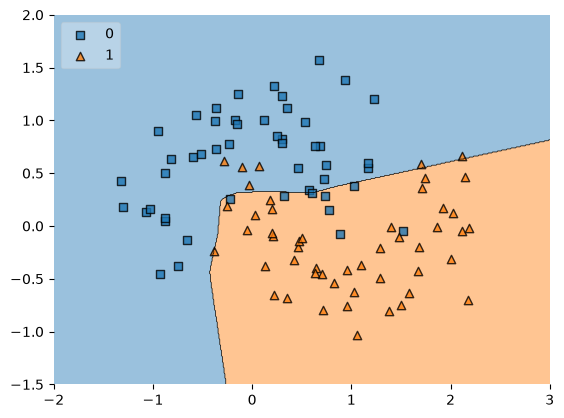

In [16]:
class ModelWrapper:
    def __init__(self, model):
        self.model = model

    def predict(self, X):
        probabilities = self.model.predict(X, verbose=0)
        return (probabilities >= 0.5).astype(int).ravel()


clf = ModelWrapper(model)

plot_decision_regions(
    X,
    y.astype(int),
    clf=clf,
    legend=2
)

plt.xlim(-2, 3)
plt.ylim(-1.5, 2)
plt.show() 